<a href="https://colab.research.google.com/github/architectma/13345d/blob/main/portfolio_2_work.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



FINAL WORK SUBMISSION FOR PROGRAMMING CYBER SECURITYM


UFCFGL-30-1




Faiza Medjek









In [ ]:
core.py
bank_system.py

Security + Validation (core.py)

In [ ]:
# core.py

import hashlib
import secrets
import re

def make_hash(data):
    return hashlib.sha256(data.encode()).hexdigest()

def password_check(pw):
    rules = {
        "length": len(pw) >= 8,
        "upper": bool(re.search(r"[A-Z]", pw)),
        "digit": bool(re.search(r"\d", pw)),
        "symbol": bool(re.search(r"[!@#$%^&*]", pw))
    }

    for key, value in rules.items():
        if not value:
            return f"Invalid password: missing {key}"
    return "OK"

def generate_key():
    return secrets.token_hex(10)

def username_check(name):
    return bool(re.match("^[A-Za-z0-9_]+$", name))

Build Main System (bank_system.py)

In [ ]:
# bank_system.py

import json
import os
from core import *

FILE = "data_store.json"
LOG = "system_log.txt"

# Load file
def read_db():
    if not os.path.exists(FILE):
        return {}
    try:
        return json.load(open(FILE))
    except:
        return {}

# Save file
def write_db(data):
    json.dump(data, open(FILE, "w"), indent=4)

# Logging
def record(event):
    with open(LOG, "a") as f:
        f.write(event + "\n")

# Register
def signup():
    db = read_db()

    user = input("Username: ")
    if not username_check(user):
        print("Invalid username")
        return

    if user in db:
        print("Already exists")
        return

    pw = input("Password: ")
    result = password_check(pw)

    if result != "OK":
        print(result)
        return

    db[user] = {
        "hash": make_hash(pw),
        "money": 0,
        "key": generate_key()
    }

    write_db(db)
    record(f"NEW USER -> {user}")

    print("Account created")
    print("Recovery key:", db[user]["key"])

# Login
def signin():
    db = read_db()
    tries = 0

    while tries < 3:
        user = input("User: ")
        pw = input("Pass: ")

        if user in db and db[user]["hash"] == make_hash(pw):
            print("Welcome!")
            record(f"LOGIN OK -> {user}")
            dashboard(user, db)
            return
        else:
            print("Wrong details")
            record(f"LOGIN FAIL -> {user}")
            tries += 1

    print("Locked!")

# Dashboard
def dashboard(user, db):
    while True:
        print("\n1.Balance 2.Deposit 3.Withdraw 4.ChangePass 5.Exit")
        ch = input(">> ")

        if ch == "1":
            print("Balance:", db[user]["money"])

        elif ch == "2":
            try:
                amt = float(input("Add: "))
                if amt > 0:
                    db[user]["money"] += amt
                    write_db(db)
                    record(f"ADD {amt} -> {user}")
            except:
                print("Invalid")

        elif ch == "3":
            try:
                amt = float(input("Take: "))
                if 0 < amt <= db[user]["money"]:
                    db[user]["money"] -= amt
                    write_db(db)
                    record(f"TAKE {amt} -> {user}")
                else:
                    print("Error")
            except:
                print("Invalid")

        elif ch == "4":
            new = input("New password: ")
            if password_check(new) != "OK":
                print("Weak password")
                continue

            db[user]["hash"] = make_hash(new)
            write_db(db)
            record(f"PASS CHANGE -> {user}")

        elif ch == "5":
            break

# Recovery
def recover():
    db = read_db()

    user = input("User: ")
    key = input("Recovery key: ")

    if user in db and db[user]["key"] == key:
        new = input("New pass: ")

        if password_check(new) != "OK":
            print("Weak")
            return

        db[user]["hash"] = make_hash(new)
        write_db(db)
        record(f"RESET -> {user}")
        print("Done")
    else:
        print("Failed")

# Main loop
def start():
    while True:
        print("\n1.SignUp 2.SignIn 3.Recover 4.Quit")
        op = input("Select: ")

        if op == "1":
            signup()
        elif op == "2":
            signin()
        elif op == "3":
            recover()
        elif op == "4":
            break
        else:
            print("Invalid")

if __name__ == "__main__":
    start()

Understand the System Goal

Before coding, define:

👉 You are building:

A secure banking system
With authentication + financial operations
Using file-based storage (JSON)
Core Features:
Register user
Login user
Deposit / Withdraw
Password security
Logging system

In [ ]:
core.py          → security + validation
bank_system.py   → main app logic
data_store.json  → user database
system_log.txt   → activity logs

Design Data Structure (VERY IMPORTANT)

In [ ]:
{
  "user1": {
    "hash": "encrypted_password",
    "money": 500,
    "key": "recovery_token"
  }
}

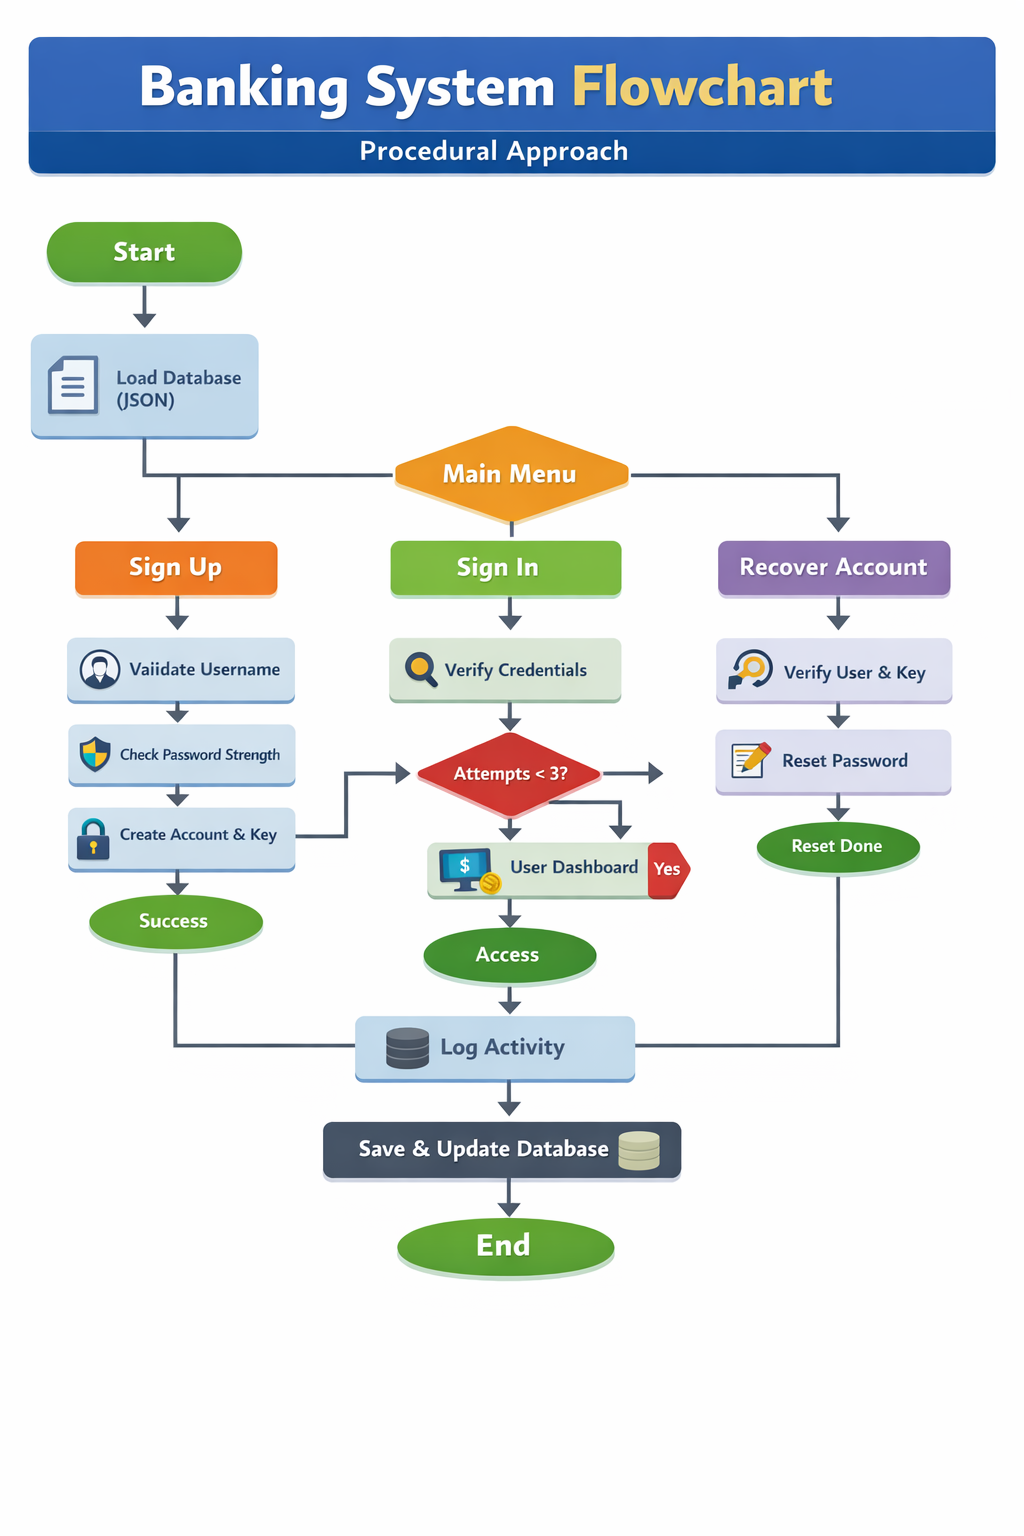

FINAL CODE OUTPUT

In [ ]:
import hashlib
import secrets
import re

# Create hashed password
def make_hash(text):
    return hashlib.sha256(text.encode()).hexdigest()

# Password validation rules
def password_check(pw):
    if len(pw) < 8:
        return "Error: Password must be at least 8 characters"
    if not re.search(r"[A-Z]", pw):
        return "Error: Must include uppercase letter"
    if not re.search(r"\d", pw):
        return "Error: Must include a number"
    if not re.search(r"[!@#$%^&*]", pw):
        return "Error: Must include special character"
    return "OK"

# Generate recovery key
def generate_key():
    return secrets.token_hex(10)

# Username validation
def username_check(name):
    return bool(re.match("^[A-Za-z0-9_]+$", name))